# Single-specimen SteelMPF calibration

In this notebook, you will:
- prepare (or inspect) filtered / resampled test data for one specimen
- choose SteelMPF seeds and which parameters to free
- set how the objective is weighted
- run L-BFGS-B and compare experimental vs simulated hysteresis

Edit the **Parameters** cell, then run the remaining cells in order.

Requires a working OpenSeesPy install (set `$env:PYTHON` / `export PYTHON=` if needed).
Results are written under `results/notebooks/single/{SPECIMEN}/`.


## Browse the specimen catalog

Before you pick a specimen name, look at what is in the repo:

- a **table** from `config/calibration/BRB-Specimens.csv` (geometry + layout flags)
- a **grid of raw hysteresis** from `data/raw/{Name}/` (unfiltered)

Path-ordered tests draw as loops; digitized tests draw as points.
Then edit **Parameters** below and choose a `Name` you like.


,Name,experimental_layout,path_ordered,f_yc_ksi,A_c_in2,A_t_in2,L_T_in,L_y_in,individual_optimize,generalized_weight
0,PC250,raw,true,41.30,5.96,59.60,251.96,179.40,true,1
1,PC350,raw,true,41.30,8.34,83.40,252.02,183.30,true,1
2,PC160,raw,true,41.30,3.80,38.00,252.00,176.00,true,1
3,PC500,raw,true,37.90,12.66,126.60,251.98,185.10,true,1
4,PC750A,raw,true,37.90,17.85,178.50,251.98,184.20,true,1
5,PC750B,raw,true,37.90,17.87,178.70,251.96,179.40,true,1
6,PC1200A,raw,true,37.90,28.53,285.30,252.02,185.20,true,1
7,PC1200B,raw,true,37.90,28.62,286.20,251.96,181.30,true,1
8,PC3SB,digitized,true,40.00,5.00,50.00,116.00,78.00,true,1
9,A5,digitized,false,44.08,5.66,56.60,215.55,148.70,false,0


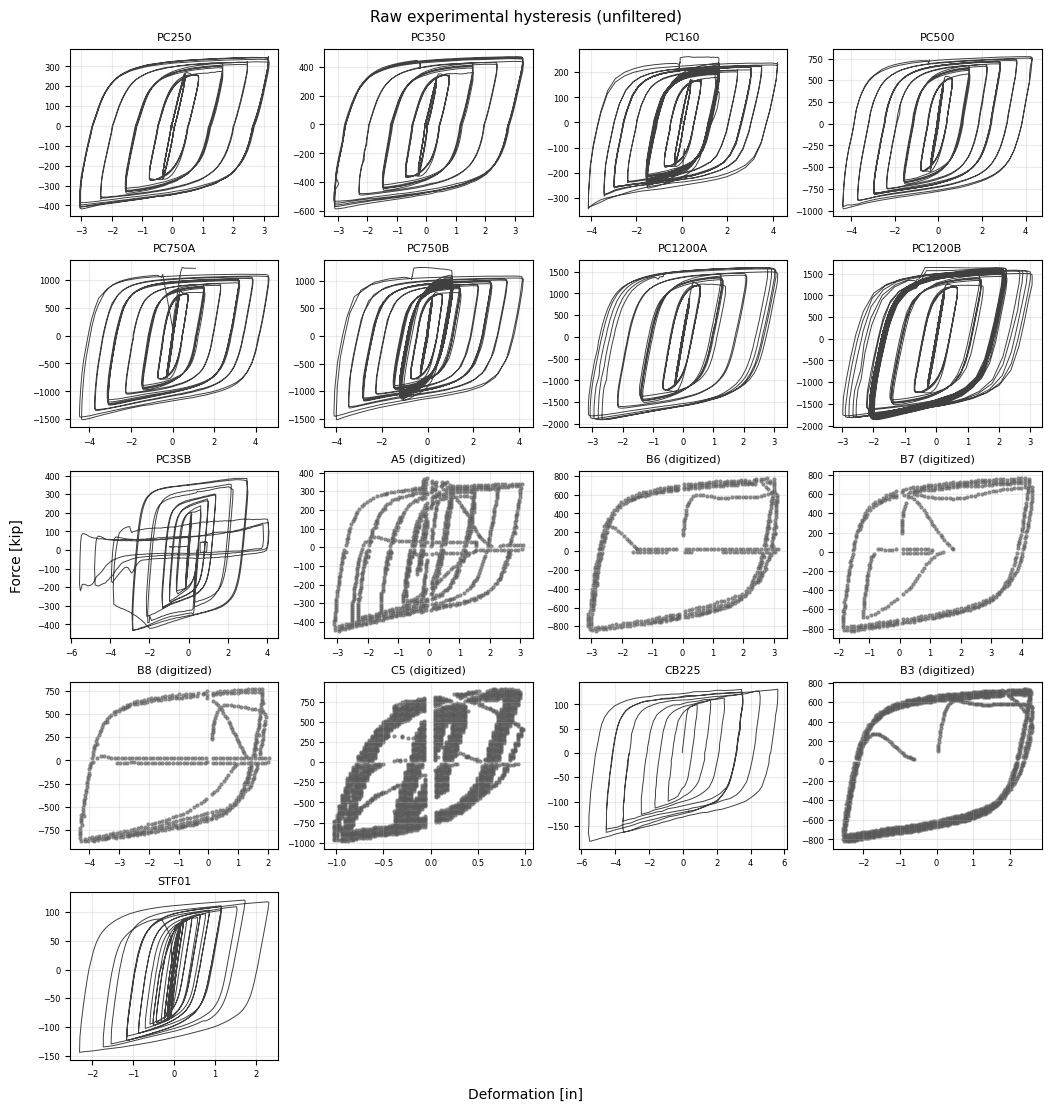

catalog rows: 17


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import show_specimen_catalog  # noqa: E402

catalog = show_specimen_catalog()
print("catalog rows:", len(catalog))


## What the objective measures

We ask the optimizer to make the model hysteresis look like the experiment.
It does that by minimizing a **weighted sum** of a few error terms:

`J_total = Σ w_k · metric_k`

| Weight | Plain-language meaning |
|--------|------------------------|
| `w_feat_l2` / `w_feat_l1` | How well we hit the **important points** on each cycle (peaks, unload, re-yield). Demos usually turn **exactly one** of these on (set to 1). |
| `w_energy_l2` / `w_energy_l1` | How well per-cycle **energy** (`|∫ F du|`) matches. Usually left at 0. |
| `w_unordered_binenv_l2` / `w_unordered_binenv_l1` | How well the **outer force envelope** matches when you only have a cloud of `(D, F)` points (digitized tests). Usually weight 0 in the fit; still reported as a diagnostic. |

Even when a weight is 0, the metrics tables still **print** that column so you can look at it.

## Amplitude weighting (inside the point-match term)

These settings do **not** add a new term. They only change how cycles are mixed
**inside** the characteristic-point error `J_feat`:

`J_feat = Σ_c w_c · j_c / Σ_c w_c`

| Setting | Effect |
|---------|--------|
| `use_amplitude_weights=False` | Every cycle counts equally (`w_c = 1`). |
| `use_amplitude_weights=True` | Larger cycles count more: `w_c = (A_c / A_max)^p + ε`. |
| `amplitude_weight_power` (`p`) | How strongly amplitude boosts the weight. |
| `amplitude_weight_eps` (`ε`) | Small floor so tiny cycles are not ignored completely. |


## Parameters

Change the values below to try a different specimen, free-parameter set, or objective.
Then run all cells below this one.


In [2]:
from pathlib import Path
import sys

# --- edit these ---
SPECIMEN = "PC160"  # many smaller cycles after the large-amplitude peaks
PREPARE_DATA = True  # build filtered/resampled from data/raw if needed

OPTIMIZE_PARAMS = ["b_p", "b_n", "R0", "cR1", "cR2", "a1", "a3"]

STEEL = {
    "E": 29000,
    "b_p": "median",   # number or apparent-b keyword: median, weighted_mean, ...
    "b_n": "median",
    "R0": 20,
    "cR1": 0.8875,
    "cR2": 0.15,
    "a1": 0.04,
    "a2": 1.0,
    "a3": 0.04,
    "a4": 1.0,
}

# Objective weights (characteristic-point L2 only is the usual default).
LOSS = {
    "w_feat_l2": 1,
    "w_feat_l1": 0,
    "w_energy_l2": 0,
    "w_energy_l1": 0,
    "w_unordered_binenv_l2": 0,
    "w_unordered_binenv_l1": 0,
    "use_amplitude_weights": True,
    "amplitude_weight_power": 2,
    "amplitude_weight_eps": 0.05,
}

# Optional: override default box bounds for free params (None -> notebook defaults)
BOUNDS = None
# ------------------

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import (  # noqa: E402
    apparent_b_summary,
    load_cycle_partition_meta,
    load_experiment_force_disp,
    params_dict_from_row,
    plot_cycle_energy_bars,
    plot_cycles_multi_axes,
    plot_prep_histories,
    plot_prep_stages,
    prepare_specimens,
    run_single_specimen,
    simulate_force_disp,
    yield_disp_from_params,
)
print("repo:", ROOT)
print("specimen:", SPECIMEN)
print("LOSS:", {k: LOSS[k] for k in LOSS if str(k).startswith("w_")})


repo: C:\Users\garaujor\source\repos\BRB-Calibration
specimen: PC160
LOSS: {'w_feat_l2': 1, 'w_feat_l1': 0, 'w_energy_l2': 0, 'w_energy_l1': 0, 'w_unordered_binenv_l2': 0, 'w_unordered_binenv_l1': 0}


## Prepare data

Before we fit, the lab record is cleaned into the drive the model will step through.

Think of three versions of the same test:

1. **Raw** — the measured force–deformation trace (invalid ends trimmed).
2. **Filtered** — same number of points, but quieter (less noise / glitches).
3. **Resampled** — fewer points along the **same** path. This is what OpenSees
   and the optimizer actually use (faster, and still faithful to the protocol).

Set `PREPARE_DATA = True` above if you want to rebuild filtered/resampled from raw
(safe to re-run). Leave it `False` if those files are already on disk.

The next cell plots two views (same idea as the report time-history figures):

- **Hysteresis** — force vs deformation (the familiar loops).
- **Histories vs point index** — raw vs filtered only (same sampling length).
- **Histories vs cumulative |Δδ|** — raw, filtered, and resampled on path length
  (`Σ|Δδ|`), so different sample counts still line up on the same protocol.
  Filtered uses a dashed line; resampled uses dash-dot.


Preparing data for 'PC160'...
  Preparing data for 'PC160'...


    cycle_points: 265 points, 265 segments (wrote JSON)


Wrote data\filtered\PC160/{force_deformation,deformation_history}.csv
    filter_force: done


  PC160: resampled n=4838 (filtered n=34100), D_sampling=0.0653679 in
    resample_filtered: done


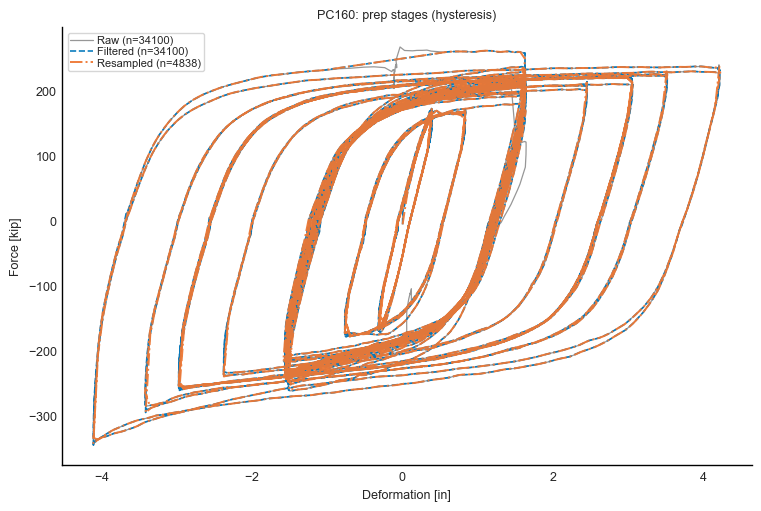

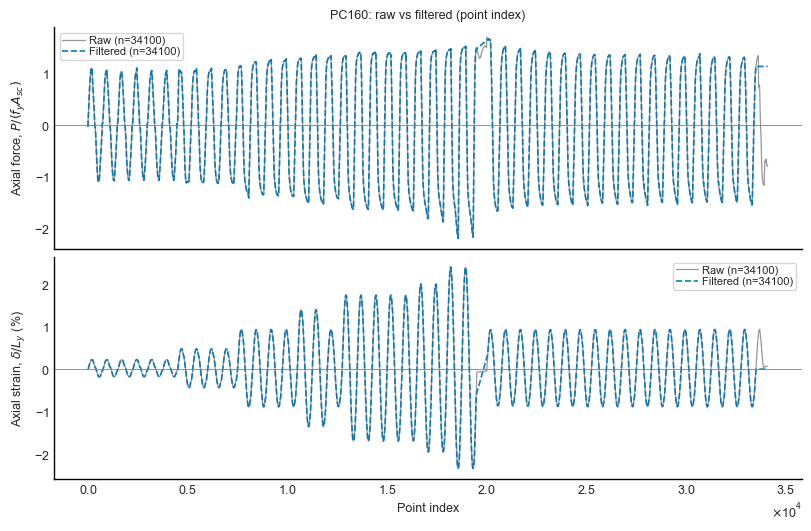

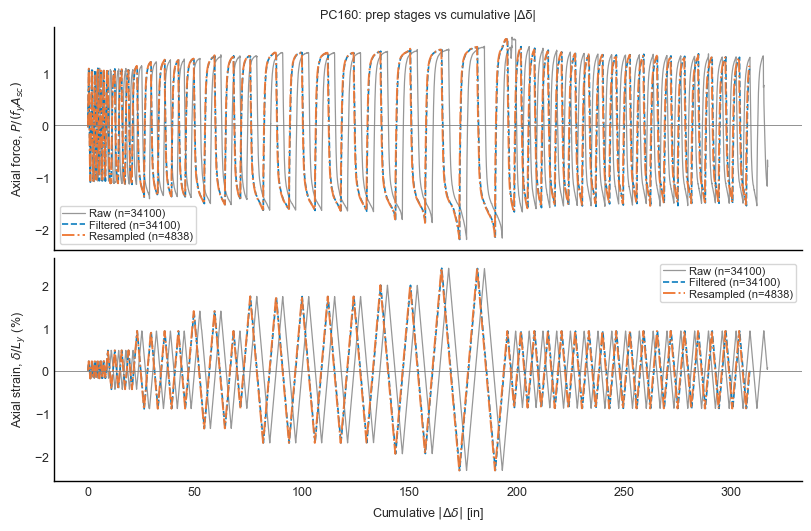

In [3]:
if PREPARE_DATA:
    prepare_specimens([SPECIMEN], e_ksi=float(STEEL["E"]))
else:
    print(f"Using existing filtered/resampled CSVs for {SPECIMEN!r} (PREPARE_DATA=False)")

plot_prep_stages(SPECIMEN)
plot_prep_histories(SPECIMEN)


## Run calibration

This starts the optimizer (L-BFGS-B), then writes fitted parameters and overlay
PNGs under `results/notebooks/single/`.

Tip: if you skipped **Prepare data**, keep `PREPARE_DATA = True` so missing
filtered/resampled files are built here automatically.


In [4]:
paths = run_single_specimen(
    SPECIMEN,
    optimize_params=OPTIMIZE_PARAMS,
    steel=STEEL,
    loss=LOSS,
    prepare_data=PREPARE_DATA,
    bounds=BOUNDS,
)
print("parameters:", paths["params"])
print("plots dir: ", paths["plots_dir"])


  Preparing data for 'PC160'...


    cycle_points: 265 points, 265 segments (wrote JSON)


Wrote data\filtered\PC160/{force_deformation,deformation_history}.csv
    filter_force: done


  PC160: resampled n=4838 (filtered n=34100), D_sampling=0.0653679 in
    resample_filtered: done
  Using force-deformation: C:\Users\garaujor\source\repos\BRB-Calibration\data\resampled\PC160\force_deformation.csv
  Input settings: set_id=1, steel_model=steelmpf
  Apparent b seeds: b_p=0.0361468 (median), b_n=0.0539225 (median)
  Optimizing: b_p, b_n, R0, cR1, cR2, a1, a3


C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\optimize_brb_mse.py:609: UserWarning: PC160: Initial b_n=0.053922543792068664 outside [0.0, 0.05]; clipped to 0.05 before optimization.
  use_norm, Ls, Us, x0, scipy_bounds = prepare_lbfgsb_parameterization(


  Best-fit SteelMPF (*=optimized):  fyp=41.3, fyn=41.3, E=29000, b_p*=0, b_n*=0.0229838, R0*=17.6087, cR1*=0.905535, cR2*=0.748469, a1*=0.0390103, a2=1, a3*=0.037316, a4=1
  final_J_total = 0.000356222


  Saved plots for PC160, set 1
  Wrote combined params: C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\single\PC160\plots\PC160_setALL_params.txt


parameters: C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\single\PC160\calibration\parameters.csv
plots dir:  C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\single\PC160\plots


## Results

Here we load the fit, re-run the model on the experimental drive, and overlay
experiment vs simulation.

Want to poke at a parameter? Change a value in `p` below and re-run **just this
cell** — no need to re-optimize.


,0
ID,3
Name,PC160
set_id,1
steel_model,steelmpf
L_T,252.0
L_y,176.0
A_sc,3.8
A_t,38.0
fyp,41.3
fyn,41.3


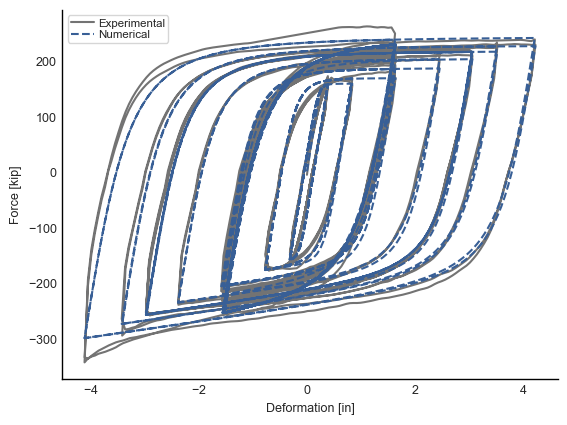

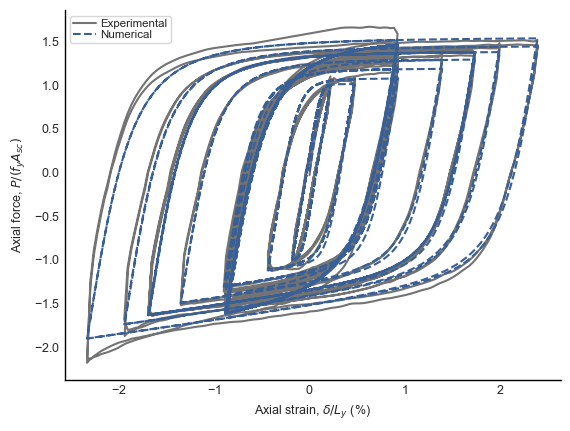

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

params = pd.read_csv(paths["params"])
display(params.T)

# Geometry + SteelMPF from the fitted row - edit any value to explore manually.
p = params_dict_from_row(params.iloc[0])
# p["b_p"] = 0.02
# p["R0"] = 18.0

exp_disp, exp_force = load_experiment_force_disp(SPECIMEN)
num_disp, num_force = simulate_force_disp(exp_disp, **p)

plt.figure()
plt.plot(exp_disp, exp_force, color="0.45", label="Experimental")
plt.plot(num_disp, num_force, linestyle="--", label="Numerical")
plt.xlabel("Deformation [in]")
plt.ylabel("Force [kip]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Normalized axes (same quantities used in the report overlays)
fyA = p["fyp"] * p["A_sc"]
plt.figure()
plt.plot(100.0 * exp_disp / p["L_y"], exp_force / fyA, color="0.45", label="Experimental")
plt.plot(100.0 * num_disp / p["L_y"], num_force / fyA, linestyle="--", label="Numerical")
plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Diagnostics

A closer look at what the objective is “looking at”:

- **Characteristic points** — one small plot per cycle, with peaks / unload /
  re-yield points numbered 1–14. **S** and **E** are cycle start and end.
  Titles show amplitude `A` and how much that cycle is weighted (`w_c`).
- **Energy** — per-cycle `|∫ F du|` for experiment vs the model.
- **Apparent b** — simple hardening slopes from the data (useful seeds / sanity check).

Changed `p` in **Results**? Re-run this cell to refresh the numerical overlays.

### Characteristic points 1–14 (plain language)

These are the same landmarks the optimizer uses. Yield force is
`F_thr = f_y A_sc`.

| # | What it marks |
|---|----------------|
| 1 | Cycle start (same as **S**) |
| 2 | First near-zero deformation after the first peak |
| 3 | Peak tension |
| 4 | Peak compression |
| 5 | Tension-side “yield” corner |
| 6 | Compression-side “yield” corner |
| 7 | Zero-force crossing at the **largest** deformation |
| 8 | Zero-force crossing at the **smallest** deformation |
| 9–12 | Half-peak / half-yield path samples (where the loop is reloading) |
| 13–14 | Partial unload after each peak (about 90% of yield force) |

Why markers often **pile up near the unload → re-yield knee**: several of those
rules intentionally sit in that band, so on a BRB loop they land close together
even though each rule is different. Small cycles may leave some slots empty.

<details>
<summary>Source files (if you want to change definitions)</summary>

- Cycle weights `w_c`: `scripts/calibrate/amplitude_mse_partition.py`
- Landmarks 1–14: `scripts/calibrate/cycle_feature_loss.py` (`extract_cycle_landmarks`)
- These plots: `scripts/examples/notebook_support.py`
  (`plot_cycles_multi_axes`, `plot_cycle_energy_bars`)

</details>


PC160: 44 weight cycles


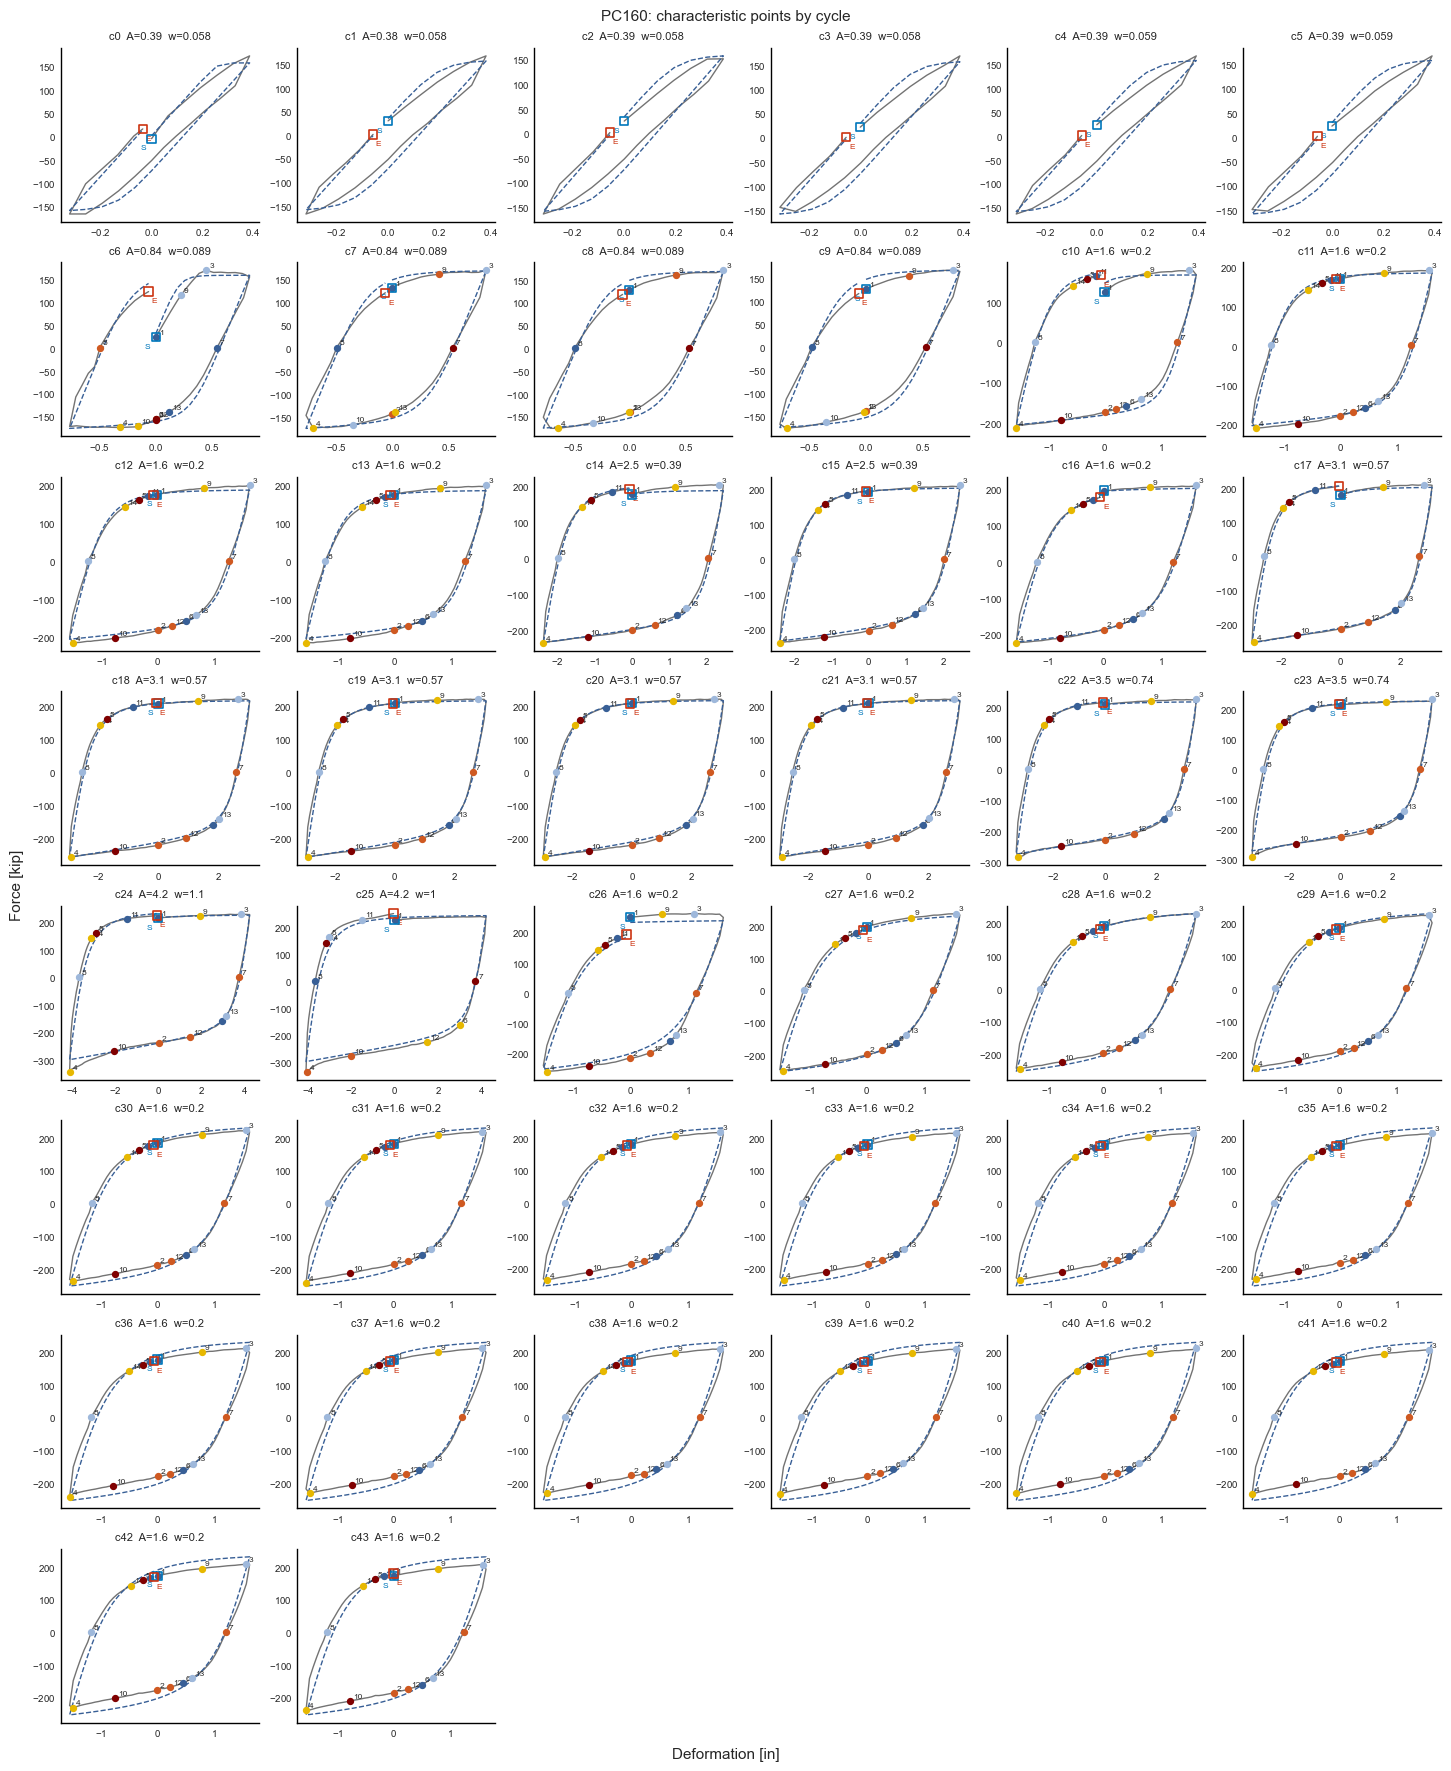

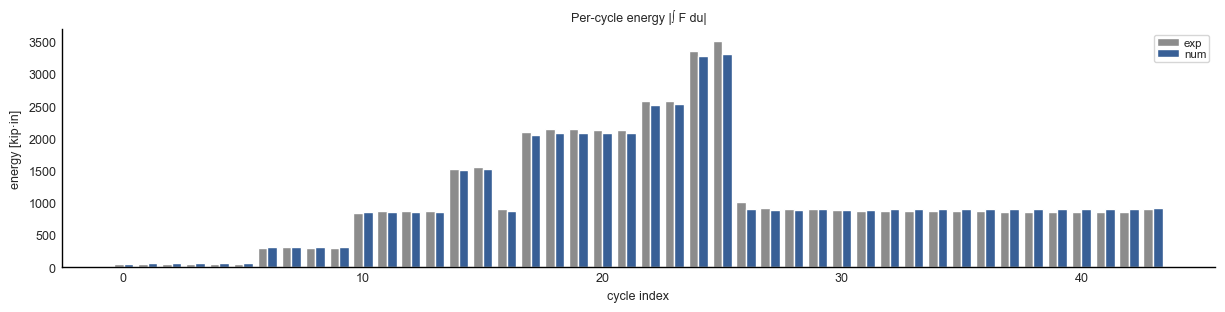

apparent b / Q:
  b_p_median: 0.0361468
  b_n_median: 0.0539225
  b_p_mean: 0.0280105
  b_n_mean: 0.0439253
  b_p_weighted_mean: 0.0207376
  b_n_weighted_mean: 0.0354754
  Q: 1.37255
  E_hat: 39803.9
fitted b_p=0, b_n=0.0229838


In [6]:
# Same partition + landmarks the optimizer uses (see paths in the markdown above).
_, _, cycle_meta = load_cycle_partition_meta(
    SPECIMEN,
    use_amplitude_weights=bool(LOSS["use_amplitude_weights"]),
    amplitude_weight_power=float(LOSS["amplitude_weight_power"]),
    amplitude_weight_eps=float(LOSS["amplitude_weight_eps"]),
)
print(f"{SPECIMEN}: {len(cycle_meta)} weight cycles")

dy = yield_disp_from_params(p)  # scripts/examples/notebook_support.py -> yield_disp_from_params
# -> scripts/calibrate/cycle_feature_loss.py -> yield_displacement_dy_in
plot_cycles_multi_axes(  # scripts/examples/notebook_support.py
    exp_disp,
    exp_force,
    cycle_meta,
    fy_ksi=p["fyp"],
    A_sc=p["A_sc"],
    dy_in=dy,
    force_num=num_force,
    ncols=6,
    title=f"{SPECIMEN}: characteristic points by cycle",
)

plot_cycle_energy_bars(  # scripts/examples/notebook_support.py
    exp_disp, exp_force, cycle_meta, force_num=num_force
)

bsum = apparent_b_summary(SPECIMEN, p)  # -> scripts/calibrate/extract_bn_bp.py
print("apparent b / Q:")
for k, v in bsum.items():
    print(f"  {k}: {v:.6g}")
print(f"fitted b_p={p['b_p']:.6g}, b_n={p['b_n']:.6g}")
